In [16]:
import pandas as pd

# 1. Caricamento del dataset scaricato da Kaggle
df = pd.read_csv("games.csv")
print(f"Partite totali nel dataset originale: {len(df)}")

# 2. LA MODIFICA: Rimuoviamo i pareggi per un modello binario puro
df = df[df['winner'] != 'draw'].copy()

# 3. Selezione delle colonne che ci interessano e pulizia dei nulli
colonne_utili = ['moves', 'white_rating', 'black_rating', 'winner']
df = df[colonne_utili].copy()
df = df.dropna()

# 4. Creazione Colonna Target e Feature Iniziale
# Ora abbiamo solo 'white' e 'black'. 
# 1 = Vittoria Bianco, 0 = Vittoria Nero
df['Vittoria_Bianco'] = (df['winner'] == 'white').astype(int)

# Calcoliamo il divario di bravura (fondamentale per aiutare il modello)
df['Differenza_Elo'] = df['white_rating'] - df['black_rating']

# 5. Filtro per le partite arrivate almeno alla mossa 20 (40 ply)
# Contiamo gli spazi nella stringa 'moves' per capire quanto è durata
df['numero_mezze_mosse'] = df['moves'].apply(lambda x: len(str(x).split()))
df_filtrato = df[df['numero_mezze_mosse'] >= 40].copy()

# 6. Salviamo solo l'essenziale per il prossimo script
df_finale = df_filtrato[['moves', 'Differenza_Elo', 'Vittoria_Bianco']].copy()

print(f"Partite valide per l'addestramento: {len(df_finale)}")
# Visualizziamo le prime 5 righe
print(df_finale.head())

Partite totali nel dataset originale: 20058
Partite valide per l'addestramento: 13616
                                               moves  Differenza_Elo  \
2  e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...              -4   
3  d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...             -15   
4  e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...              54   
8  e4 e5 Bc4 Nc6 Nf3 Nd4 d3 Nxf3+ Qxf3 Nf6 h3 Bc5...              47   
9  e4 d5 exd5 Qxd5 Nc3 Qe5+ Be2 Na6 d4 Qf5 Bxa6 b...             172   

   Vittoria_Bianco  
2                1  
3                1  
4                1  
8                0  
9                1  


In [2]:
import pandas as pd
import chess

# Dizionario con il numero esatto di pezzi a inizio partita
# Maiuscole = Bianco, Minuscole = Nero
pezzi_standard = {
    'P': 8, 'N': 2, 'B': 2, 'R': 2, 'Q': 1, 'K': 1,
    'p': 8, 'n': 2, 'b': 2, 'r': 2, 'q': 1, 'k': 1
}

def estrai_coordinate(mosse_str):
    """
    Gioca la partita fino alla mossa 20 (40 ply) ed estrae le coordinate X,Y.
    """
    board = chess.Board()
    mosse = str(mosse_str).split()
    
    # Facciamo avanzare la partita di esattamente 40 mezze-mosse
    for mossa in mosse[:40]:
        try:
            board.push_san(mossa)
        except:
            break
            
    # Contatori per tracciare quanti pezzi di ogni tipo troviamo
    trovati = {pezzo: 0 for pezzo in pezzi_standard.keys()}
    coord_dict = {}
    
    # Scansioniamo tutte le 64 case della scacchiera
    for square in chess.SQUARES:
        pezzo = board.piece_at(square)
        if pezzo:
            simbolo = pezzo.symbol()
            trovati[simbolo] += 1
            indice = trovati[simbolo]
            
            # Calcoliamo X (colonna) e Y (riga) da 1 a 8
            # La libreria ci dà metodi comodi per file (0-7) e rank (0-7)
            x = chess.square_file(square) + 1
            y = chess.square_rank(square) + 1
            
            coord_dict[f"{simbolo}_{indice}_X"] = x
            coord_dict[f"{simbolo}_{indice}_Y"] = y
            
    # GESTIONE DEI PEZZI CATTURATI (Trucco di Navid)
    # Se abbiamo trovato meno pezzi del previsto, assegniamo (0,0) ai restanti
    for simbolo, max_count in pezzi_standard.items():
        count_trovati = trovati[simbolo]
        for i in range(count_trovati + 1, max_count + 1):
            coord_dict[f"{simbolo}_{i}_X"] = 0
            coord_dict[f"{simbolo}_{i}_Y"] = 0
            
    return coord_dict

print("Estrazione delle coordinate in corso... (potrebbe volerci qualche decina di secondi)")

# 1. Applichiamo la funzione a tutte le righe del dataframe della Fase 1
lista_dizionari = df_finale['moves'].apply(estrai_coordinate).tolist()

# 2. Convertiamo la lista di dizionari in un nuovo DataFrame Pandas
df_coordinate = pd.DataFrame(lista_dizionari)

# 3. Uniamo le coordinate con la Differenza Elo e il Target
# (Resettiamo l'indice per assicurarci che si uniscano perfettamente riga per riga)
df_finale = df_finale.reset_index(drop=True)
df_ml = pd.concat([df_finale[['Differenza_Elo', 'Vittoria_Bianco']], df_coordinate], axis=1)

print("Dataset per il Machine Learning creato con successo!")
print(f"Dimensioni del dataset: {df_ml.shape[0]} righe e {df_ml.shape[1]} colonne.")
print(df_ml.head())

Estrazione delle coordinate in corso... (potrebbe volerci qualche decina di secondi)
Dataset per il Machine Learning creato con successo!
Dimensioni del dataset: 13616 righe e 72 colonne.
   Differenza_Elo  Vittoria_Bianco  Q_1_X  Q_1_Y  K_1_X  K_1_Y  N_1_X  N_1_Y  \
0              -4                1      4      1      5      1      7      1   
1             -15                1      2      8      7      1      6      3   
2              54                1      4      3      7      1      6      3   
3              47                0      6      3      7      1      3      1   
4             172                1      0      0      5      1      1      6   

   R_1_X  R_1_Y  ...  r_2_X  r_2_Y  q_1_X  q_1_Y  Q_2_X  Q_2_Y  R_3_X  R_3_Y  \
0      8      1  ...      0      0      0      0    NaN    NaN    NaN    NaN   
1      1      1  ...      0      0      0      0    NaN    NaN    NaN    NaN   
2      1      1  ...      0      0      6      6    NaN    NaN    NaN    NaN   
3      1   

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Inizio Fase 3: Preparazione dei dati per il Machine Learning...")
df_ml = df_ml.fillna(0)
# 1. Separazione delle Features (X) e del Target (y)
# X conterrà le 65 colonne (Differenza_Elo + le 64 coordinate)
# y conterrà solo 1 o 0
X = df_ml.drop(columns=['Vittoria_Bianco'])
y = df_ml['Vittoria_Bianco']

# 2. Train/Test Split (80% addestramento, 20% test)
# random_state=42 assicura che il taglio sia riproducibile (se lo rilanciate, dividerà i dati sempre allo stesso modo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Partite per l'addestramento (Train): {len(X_train)}")
print(f"Partite per la validazione (Test): {len(X_test)}")

# 3. Inizializzazione dello StandardScaler
scaler = StandardScaler()

# 4. Standardizzazione
# IL TRUCCO: impariamo le regole (fit) e le applichiamo (transform) SOLO sul Train
X_train_scaled = scaler.fit_transform(X_train)

# Sul Test ci limitiamo ad applicare (transform) le regole imparate dal Train
X_test_scaled = scaler.transform(X_test)

print("\nStandardizzazione completata con successo!")
print("Esempio: La 'Differenza_Elo' e le 'Coordinate' ora hanno media ~0 e deviazione standard 1.")

Inizio Fase 3: Preparazione dei dati per il Machine Learning...
Partite per l'addestramento (Train): 10892
Partite per la validazione (Test): 2724

Standardizzazione completata con successo!
Esempio: La 'Differenza_Elo' e le 'Coordinate' ora hanno media ~0 e deviazione standard 1.


In [4]:
import time
from sklearn.linear_model import LogisticRegression

print("--- INIZIO FASE 4: ADDESTRAMENTO E CONFRONTO OTTIMIZZATORI ---")

# =====================================================================
# MODELLO A: Variate dello Steepest Descent (SAGA)
# Utilizza solo il Gradiente (derivata prima)
# =====================================================================
print("\n1. Addestramento Modello A (Solver: SAGA / Steepest Descent)...")
modello_saga = LogisticRegression(solver='saga', max_iter=2000, random_state=42)

start_time_saga = time.time()
modello_saga.fit(X_train_scaled, y_train)
end_time_saga = time.time()

tempo_saga = end_time_saga - start_time_saga
iterazioni_saga = modello_saga.n_iter_[0]

print(f"✅ SAGA completato in {tempo_saga:.3f} secondi.")
print(f"👣 Iterazioni (passi) necessari: {iterazioni_saga}")


# =====================================================================
# MODELLO B: Metodo Quasi-Newton (L-BFGS)
# Approssima la matrice Hessiana (derivata seconda)
# =====================================================================
print("\n2. Addestramento Modello B (Solver: L-BFGS / Quasi-Newton)...")
modello_lbfgs = LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42)

start_time_lbfgs = time.time()
modello_lbfgs.fit(X_train_scaled, y_train)
end_time_lbfgs = time.time()

tempo_lbfgs = end_time_lbfgs - start_time_lbfgs
iterazioni_lbfgs = modello_lbfgs.n_iter_[0]

print(f"✅ L-BFGS completato in {tempo_lbfgs:.3f} secondi.")
print(f"👣 Iterazioni (passi) necessari: {iterazioni_lbfgs}")

print("\n--- ADDESTRAMENTO COMPLETATO ---")

--- INIZIO FASE 4: ADDESTRAMENTO E CONFRONTO OTTIMIZZATORI ---

1. Addestramento Modello A (Solver: SAGA / Steepest Descent)...
✅ SAGA completato in 4.405 secondi.
👣 Iterazioni (passi) necessari: 637

2. Addestramento Modello B (Solver: L-BFGS / Quasi-Newton)...
✅ L-BFGS completato in 0.125 secondi.
👣 Iterazioni (passi) necessari: 29

--- ADDESTRAMENTO COMPLETATO ---


--- INIZIO FASE 5: VALUTAZIONE DELLE PERFORMANCE ---

Confronto Previsioni: I due modelli hanno dato la stessa risposta nel 99.96% dei casi!
Questo dimostra che entrambi i solver sono conversi allo stesso minimo globale della funzione convessa.

--- CLASSIFICATION REPORT (Modello L-BFGS) ---
                     precision    recall  f1-score   support

  Vittoria Nero (0)       0.68      0.69      0.69      1337
Vittoria Bianco (1)       0.70      0.69      0.69      1387

           accuracy                           0.69      2724
          macro avg       0.69      0.69      0.69      2724
       weighted avg       0.69      0.69      0.69      2724


Generazione della Matrice di Confusione in corso...


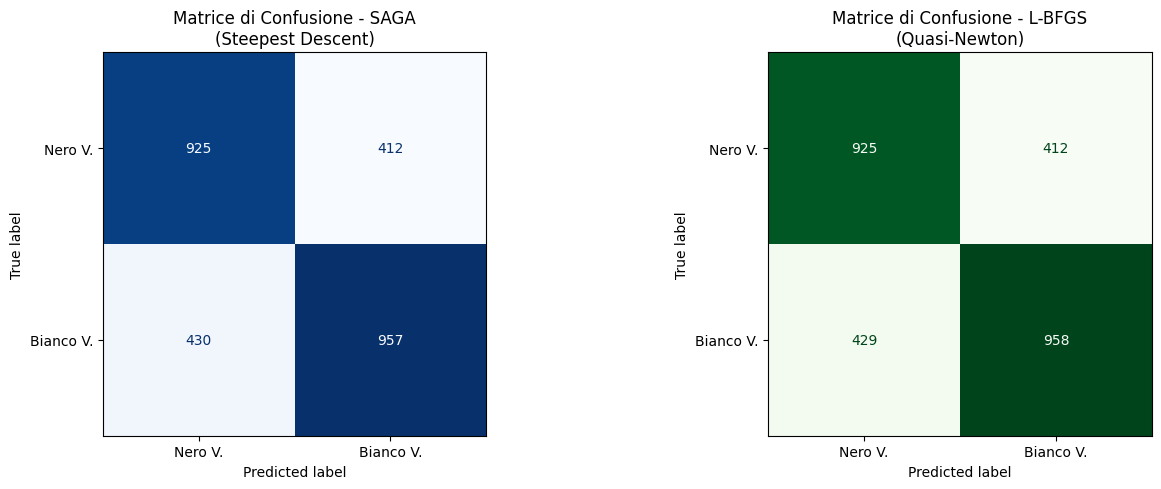

--- VALUTAZIONE COMPLETATA ---


In [5]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- INIZIO FASE 5: VALUTAZIONE DELLE PERFORMANCE ---")

# 1. Generiamo le previsioni sui dati di Test (il 20% che il modello non ha mai visto)
y_pred_saga = modello_saga.predict(X_test_scaled)
y_pred_lbfgs = modello_lbfgs.predict(X_test_scaled)

# 2. Rispondiamo alla domanda di Navid: le previsioni sono diverse?
previsioni_uguali = (y_pred_saga == y_pred_lbfgs).sum()
totale_test = len(y_test)
percentuale_uguaglianza = (previsioni_uguali / totale_test) * 100

print(f"\nConfronto Previsioni: I due modelli hanno dato la stessa risposta nel {percentuale_uguaglianza:.2f}% dei casi!")
print("Questo dimostra che entrambi i solver sono conversi allo stesso minimo globale della funzione convessa.")

# 3. Metriche Classiche (Usiamo i risultati di L-BFGS, visto che sono uguali)
print("\n--- CLASSIFICATION REPORT (Modello L-BFGS) ---")
print(classification_report(y_test, y_pred_lbfgs, target_names=['Vittoria Nero (0)', 'Vittoria Bianco (1)']))

# 4. Matrici di Confusione
print("\nGenerazione della Matrice di Confusione in corso...")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Matrice SAGA
cm_saga = confusion_matrix(y_test, y_pred_saga)
disp_saga = ConfusionMatrixDisplay(confusion_matrix=cm_saga, display_labels=['Nero V.', 'Bianco V.'])
disp_saga.plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Matrice di Confusione - SAGA\n(Steepest Descent)')

# Plot Matrice L-BFGS
cm_lbfgs = confusion_matrix(y_test, y_pred_lbfgs)
disp_lbfgs = ConfusionMatrixDisplay(confusion_matrix=cm_lbfgs, display_labels=['Nero V.', 'Bianco V.'])
disp_lbfgs.plot(ax=ax[1], cmap='Greens', colorbar=False)
ax[1].set_title('Matrice di Confusione - L-BFGS\n(Quasi-Newton)')

plt.tight_layout()
plt.show()

print("--- VALUTAZIONE COMPLETATA ---")

--- INIZIO FASE 6: ANALISI DELLA CONVERGENZA ---


C:\Users\teosp\AppData\Local\Temp\ipykernel_21716\3861082837.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelli, y=tempi, ax=ax[0], palette=['#3498db', '#2ecc71'])
C:\Users\teosp\AppData\Local\Temp\ipykernel_21716\3861082837.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelli, y=iterazioni, ax=ax[1], palette=['#e74c3c', '#f1c40f'])


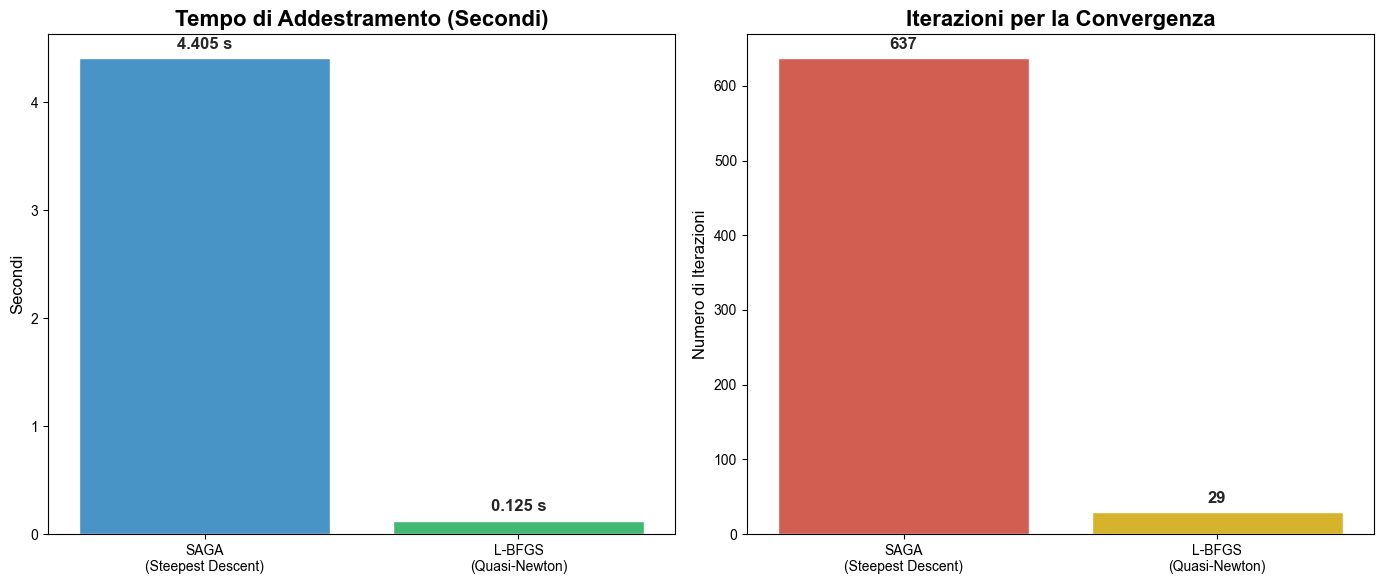

--- ANALISI DELLA CONVERGENZA COMPLETATA ---


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INIZIO FASE 6: ANALISI DELLA CONVERGENZA ---")

# 1. Prepariamo i dati da plottare
modelli = ['SAGA\n(Steepest Descent)', 'L-BFGS\n(Quasi-Newton)']
tempi = [tempo_saga, tempo_lbfgs]
iterazioni = [iterazioni_saga, iterazioni_lbfgs]

# 2. Impostazione della figura con due grafici affiancati
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid")

# --- Grafico 1: Tempo di Addestramento ---
sns.barplot(x=modelli, y=tempi, ax=ax[0], palette=['#3498db', '#2ecc71'])
ax[0].set_title('Tempo di Addestramento (Secondi)', fontsize=16, fontweight='bold')
ax[0].set_ylabel('Secondi', fontsize=12)

# Aggiungiamo le etichette con il valore esatto sopra le barre
for i, v in enumerate(tempi):
    ax[0].text(i, v + (max(tempi)*0.02), f"{v:.3f} s", ha='center', fontsize=12, fontweight='bold')

# --- Grafico 2: Numero di Iterazioni ---
sns.barplot(x=modelli, y=iterazioni, ax=ax[1], palette=['#e74c3c', '#f1c40f'])
ax[1].set_title('Iterazioni per la Convergenza', fontsize=16, fontweight='bold')
ax[1].set_ylabel('Numero di Iterazioni', fontsize=12)

for i, v in enumerate(iterazioni):
    ax[1].text(i, v + (max(iterazioni)*0.02), str(v), ha='center', fontsize=12, fontweight='bold')

# 3. Mostriamo il capolavoro
plt.tight_layout()
plt.show()

print("--- ANALISI DELLA CONVERGENZA COMPLETATA ---")

## Fase 7: Explainable AI (XAI) — Analisi del Processo Decisionale

### Perché XAI anche su un modello White Box?

La Regressione Logistica è già un modello **White Box**: conosciamo i suoi pesi $w_j$.
Tuttavia, guardare 65 numeri $w_j$ grezzi risponde poco alle domande che contano:

- Quale feature ha **contato di più** in questa partita specifica?
- La posizione dei pezzi ha davvero influenzato la previsione, o ha dominato solo l'Elo?

**SHAP** (*SHapley Additive exPlanations*) risponde a queste domande in modo matematicamente fondato,
partendo dalla teoria dei giochi cooperativi di Lloyd Shapley (Premio Nobel 2012).

### Il fondamento: il Valore di Shapley

Le 65 feature sono trattate come **giocatori** di una squadra; la previsione è il **premio** da distribuire equamente tra loro.

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \Big[ v(S \cup \{i\}) - v(S) \Big]$$

Per il nostro modello **lineare**, questa formula si semplifica in modo esatto:

$$\boxed{\phi_j = w_j \cdot (x_j - \mathbb{E}[x_j])}$$

I pesi $w_j$ sono esattamente quelli trovati da SAGA e L-BFGS nelle Fasi precedenti.
Questo è il **filo matematico** del progetto: ottimizzazione → predizione → spiegazione.

### Le tre analisi che eseguiamo

| Analisi | Domanda | Tipo |
|---------|---------|------|
| **7a** — Summary Plot (beeswarm) | Quali feature contano di più in media su tutto il dataset? | Globale |
| **7b** — Waterfall Plot | Come si costruisce la previsione su una singola partita? | Locale |
| **7c** — Confronto SAGA vs L-BFGS | I due ottimizzatori producono la stessa spiegazione? | Verifica matematica |

In [7]:
# ============================================================
# FASE 7a — CALCOLO VALORI SHAP
# ============================================================
# Usiamo LinearExplainer: lo strumento SHAP per modelli lineari.
# Sfrutta la formula chiusa phi_j = w_j * (x_j - E[x_j]),
# quindi il calcolo è ESATTO, non approssimato.
#
# X_train_scaled serve come "background": da esso SHAP calcola
# E[x_j], cioè il valore medio di ogni feature sul training set.
# Questo diventa il "punto di partenza" (baseline) delle spiegazioni.
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("=" * 60)
print("   FASE 7 — EXPLAINABLE AI CON SHAP")
print("=" * 60)

# Un LinearExplainer per ciascun ottimizzatore
# (ci servono entrambi per il confronto in 7c)
print("\n[1/3] Inizializzazione LinearExplainer...")
explainer_lbfgs = shap.LinearExplainer(modello_lbfgs, X_train_scaled)
explainer_saga  = shap.LinearExplainer(modello_saga,  X_train_scaled)
print("      OK")

# Calcolo della matrice SHAP sul test set
# Forma: (n_partite_test, 65)
# phi_j > 0 → spinge verso Vittoria Bianco
# phi_j < 0 → spinge verso Vittoria Nero
print("\n[2/3] Calcolo valori SHAP sul Test Set...")
shap_values_lbfgs = explainer_lbfgs.shap_values(X_test_scaled)
shap_values_saga  = explainer_saga.shap_values(X_test_scaled)
print(f"      OK — matrice SHAP: {shap_values_lbfgs.shape}")

# Nomi delle feature e DataFrame leggibile
nomi_feature  = X.columns.tolist()
df_shap_lbfgs = pd.DataFrame(shap_values_lbfgs, columns=nomi_feature)
df_shap_saga  = pd.DataFrame(shap_values_saga,  columns=nomi_feature)

# Importanza globale: media del VALORE ASSOLUTO di phi_j
# Il valore assoluto è fondamentale: una feature importante che
# a volte aiuta il Bianco e a volte il Nero avrebbe media ≈ 0
# senza il valore assoluto, apparendo erroneamente irrilevante.
importanza_globale = df_shap_lbfgs.abs().mean().sort_values(ascending=False)

print("\n[3/3] Top 10 Feature per Importanza SHAP Globale E[|phi_j|]:")
print("-" * 50)
for i, (feat, val) in enumerate(importanza_globale.head(10).items(), 1):
    print(f"  {i:>2}. {feat:<28}  {val:.5f}")
print("-" * 50)

   FASE 7 — EXPLAINABLE AI CON SHAP

[1/3] Inizializzazione LinearExplainer...
      OK

[2/3] Calcolo valori SHAP sul Test Set...
      OK — matrice SHAP: (2724, 71)

[3/3] Top 10 Feature per Importanza SHAP Globale E[|phi_j|]:
--------------------------------------------------
   1. Differenza_Elo                0.50698
   2. r_2_Y                         0.31802
   3. R_2_X                         0.27181
   4. p_7_Y                         0.26098
   5. Q_1_Y                         0.25038
   6. q_1_X                         0.23577
   7. Q_1_X                         0.22868
   8. N_2_Y                         0.19661
   9. P_6_Y                         0.17025
  10. b_2_Y                         0.15909
--------------------------------------------------


--- 7a: SUMMARY PLOT SHAP ---
Risponde a: quali feature contano di più IN MEDIA su tutto il dataset?



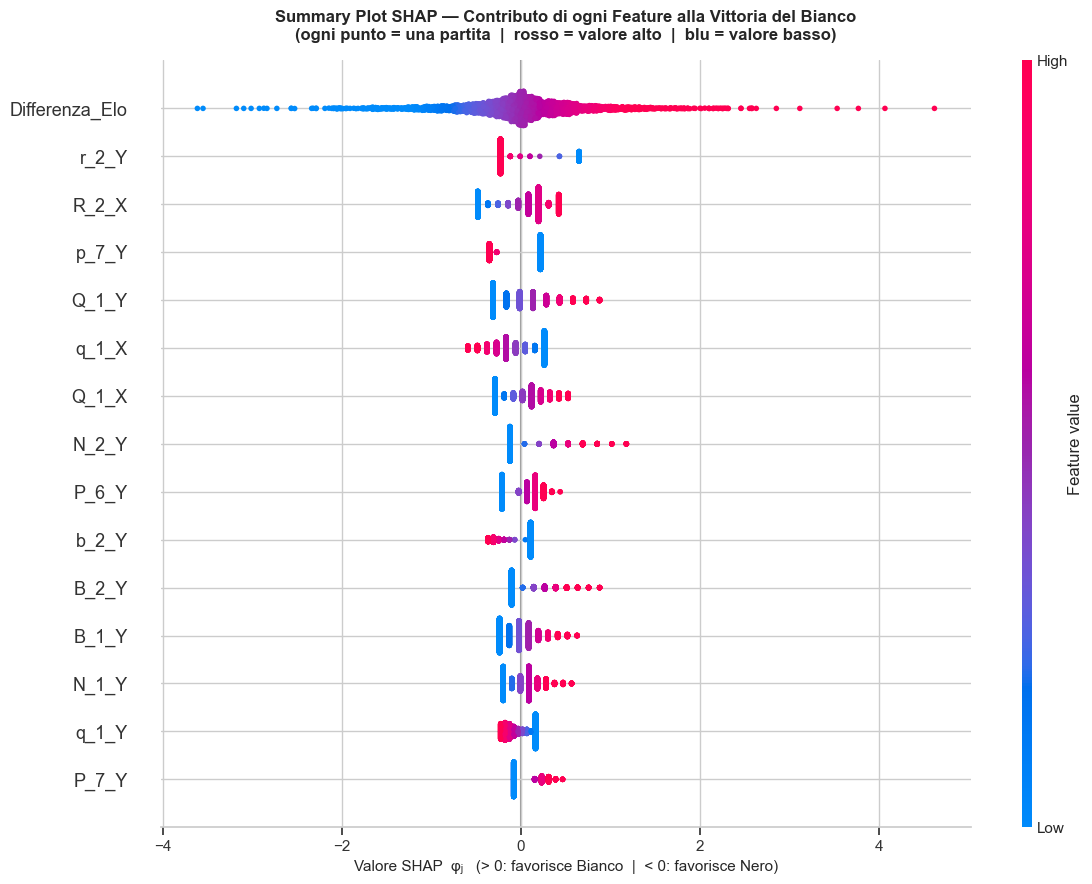

Grafico 7a completato.


In [8]:
# ============================================================
# FASE 7a — SUMMARY PLOT (BEESWARM)
# ============================================================
# Il Summary Plot è il grafico "firma" di SHAP
#
# Come si legge:
#   Asse Y  → feature ordinate per importanza (la più importante in cima)
#   Asse X  → valore phi_j per ogni partita del test set
#              > 0 = spinge verso Vittoria Bianco
#              < 0 = spinge verso Vittoria Nero
#   Colore  → valore della feature in quella partita
#              ROSSO = valore alto (es. pezzo avanzato, in riga 7)
#              BLU   = valore basso (es. pezzo catturato, coord 0)
#
# Ogni PUNTO è una partita. La nuvola di punti mostra non solo
# QUANTO conta una feature in media, ma QUANDO conta di più:
# se i punti rossi sono a destra, valori alti della feature
# favoriscono il Bianco; se sono a sinistra, favoriscono il Nero.
# ============================================================

print("--- 7a: SUMMARY PLOT SHAP ---")
print("Risponde a: quali feature contano di più IN MEDIA su tutto il dataset?\n")

plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_values_lbfgs,
    X_test_scaled,
    feature_names=nomi_feature,
    max_display=15,
    show=False,
    plot_size=None
)
plt.title(
    "Summary Plot SHAP — Contributo di ogni Feature alla Vittoria del Bianco\n"
    "(ogni punto = una partita  |  rosso = valore alto  |  blu = valore basso)",
    fontsize=12, fontweight='bold', pad=15
)
plt.xlabel("Valore SHAP  φⱼ   (> 0: favorisce Bianco  |  < 0: favorisce Nero)",
           fontsize=11)
plt.tight_layout()
plt.show()
print("Grafico 7a completato.")

--- 7a (bis): BAR PLOT IMPORTANZA SHAP PER TIPO DI PEZZO ---



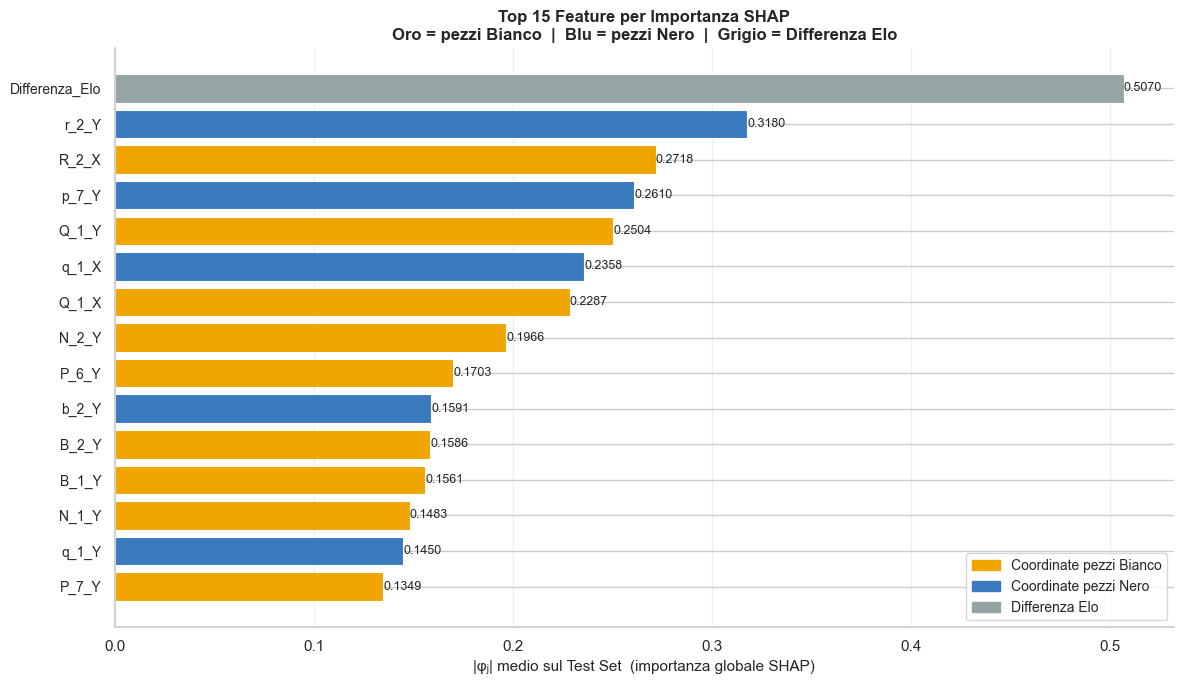

Grafico 7a (bar plot) completato.


In [9]:
# ============================================================
# FASE 7a — BAR PLOT COLORATO PER TIPO DI PEZZO
# ============================================================
# Questo secondo grafico è complementare al beeswarm:
# mostra E[|phi_j|] per ogni feature con un colore diverso
# in base a quale "squadra" appartiene il pezzo.
#
# Colori:
#   ORO   → pezzi del Bianco (simbolo maiuscolo: P, N, B, R, Q, K)
#   BLU   → pezzi del Nero   (simbolo minuscolo: p, n, b, r, q, k)
#   GRIGIO → Differenza Elo
#
# Questo rende subito visibile quale squadra domina l'importanza:
# se le barre dorate dominano, la posizione del Bianco conta di più;
# se dominano le blu, conta di più la posizione del Nero.
# ============================================================

print("--- 7a (bis): BAR PLOT IMPORTANZA SHAP PER TIPO DI PEZZO ---\n")

top_n       = 15
top_features = importanza_globale.head(top_n)

def colore_feature(nome):
    if nome == "Differenza_Elo":
        return "#95a5a6"          # grigio
    return "#f0a500" if nome[0].isupper() else "#3a7abf"  # oro o blu

colori = [colore_feature(f) for f in top_features.index]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(top_n), top_features.values,
               color=colori, edgecolor='white', linewidth=0.8)

# Valore numerico a fianco di ogni barra
for bar, val in zip(bars, top_features.values):
    ax.text(val + 0.00015, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va='center', fontsize=9)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("|φⱼ| medio sul Test Set  (importanza globale SHAP)", fontsize=11)
ax.set_title(
    f"Top {top_n} Feature per Importanza SHAP\n"
    "Oro = pezzi Bianco  |  Blu = pezzi Nero  |  Grigio = Differenza Elo",
    fontsize=12, fontweight='bold'
)

legenda = [
    mpatches.Patch(color="#f0a500", label="Coordinate pezzi Bianco"),
    mpatches.Patch(color="#3a7abf", label="Coordinate pezzi Nero"),
    mpatches.Patch(color="#95a5a6", label="Differenza Elo"),
]
ax.legend(handles=legenda, loc='lower right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print("Grafico 7a (bar plot) completato.")

### 7a — Come si legge il Summary Plot

Il beeswarm è più informativo di un semplice bar plot perché mostra la **distribuzione completa**:

- Se la nuvola di **punti rossi** (valore feature alto) è a **destra** di zero → valori alti di quella feature **favoriscono il Bianco**
- Se i **punti rossi** sono a **sinistra** → valori alti **favoriscono il Nero**
- Se i punti sono sparsi su entrambi i lati → l'effetto dipende da altre variabili (interazione)

Per esempio: se `Differenza_Elo` ha punti rossi a destra, il modello ha imparato che
un Bianco molto più forte tende a vincere — il che è corretto scacchisticamente.

--- 7b: WATERFALL PLOT (Spiegazione Locale) ---
Risponde a: come si costruisce la previsione su UNA partita specifica?



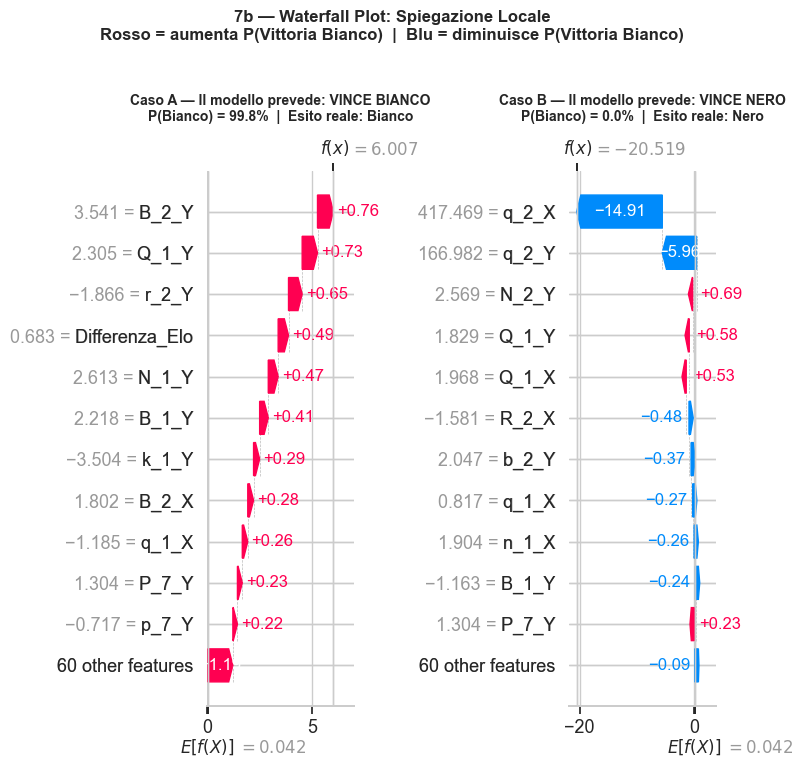


Come leggere il grafico:
  E[f(x)] = previsione MEDIA del modello (baseline, senza info specifiche)
  Barre rosse = feature che AUMENTANO la probabilità vittoria Bianco
  Barre blu   = feature che DIMINUISCONO la probabilità vittoria Bianco
  f(x) = previsione FINALE: E[f(x)] + somma di tutte le barre

Grafico 7b completato.


In [10]:
# ============================================================
# FASE 7b — WATERFALL PLOT (SPIEGAZIONE LOCALE)
# ============================================================
# Il Waterfall Plot risponde alla domanda LOCALE:
# "Come si costruisce la previsione su UNA partita specifica?"
#
# Come funziona:
#   - Si parte da E[f(x)]: la previsione MEDIA del modello
#     su tutto il training set (baseline, senza info specifiche)
#   - Ogni feature aggiunge o sottrae con il suo phi_j
#   - Si arriva alla previsione finale f(x) per quella partita
#
# La somma è garantita dalla proprietà di EFFICIENZA di SHAP:
#   f(x) = E[f(x)] + sum_j(phi_j)
#
# Mostrato dal professore in Dimensions.ipynb:
#   shap.plots.waterfall(shap_values[4])
# ============================================================

print("--- 7b: WATERFALL PLOT (Spiegazione Locale) ---")
print("Risponde a: come si costruisce la previsione su UNA partita specifica?\n")

# Costruiamo l'oggetto Explanation (formato ricco di SHAP,
# include baseline, valori SHAP e nomi delle feature)
shap_explanation = shap.Explanation(
    values        = shap_values_lbfgs,
    base_values   = explainer_lbfgs.expected_value,
    data          = X_test_scaled,
    feature_names = nomi_feature
)

# Selezioniamo due partite rappresentative:
# una dove il modello è sicuro che vince il Bianco,
# una dove è sicuro che vince il Nero.
prob_bianco      = modello_lbfgs.predict_proba(X_test_scaled)[:, 1]
idx_bianco_forte = int(np.argmax(prob_bianco))
idx_nero_forte   = int(np.argmin(prob_bianco))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.waterfall_plot(shap_explanation[idx_bianco_forte],
                    max_display=12, show=False)
axes[0].set_title(
    f"Caso A — Il modello prevede: VINCE BIANCO\n"
    f"P(Bianco) = {prob_bianco[idx_bianco_forte]:.1%}  |  "
    f"Esito reale: {'Bianco' if y_test.iloc[idx_bianco_forte]==1 else 'Nero'}",
    fontsize=10, fontweight='bold', pad=12
)

plt.sca(axes[1])
shap.waterfall_plot(shap_explanation[idx_nero_forte],
                    max_display=12, show=False)
axes[1].set_title(
    f"Caso B — Il modello prevede: VINCE NERO\n"
    f"P(Bianco) = {prob_bianco[idx_nero_forte]:.1%}  |  "
    f"Esito reale: {'Bianco' if y_test.iloc[idx_nero_forte]==1 else 'Nero'}",
    fontsize=10, fontweight='bold', pad=12
)

plt.suptitle(
    "7b — Waterfall Plot: Spiegazione Locale\n"
    "Rosso = aumenta P(Vittoria Bianco)  |  Blu = diminuisce P(Vittoria Bianco)",
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()
print("\nCome leggere il grafico:")
print("  E[f(x)] = previsione MEDIA del modello (baseline, senza info specifiche)")
print("  Barre rosse = feature che AUMENTANO la probabilità vittoria Bianco")
print("  Barre blu   = feature che DIMINUISCONO la probabilità vittoria Bianco")
print("  f(x) = previsione FINALE: E[f(x)] + somma di tutte le barre")
print("\nGrafico 7b completato.")

### 7b — Come si legge il Waterfall Plot

Il grafico si legge **dal basso verso l'alto**:

- **E[f(x)]** (numero in basso): la previsione *media* del modello — punto di partenza
- Ogni barra mostra il contributo $\phi_j$ di una feature: rossa se positivo (aiuta il Bianco), blu se negativo
- **f(x)** (numero in alto): la previsione finale per quella partita

La formula che li collega è la proprietà di **Efficienza** di SHAP:
$$f(x) = \mathbb{E}[f(x)] + \sum_{j=1}^{65} \phi_j$$

Confrontando i Casi A e B si vede chiaramente come le stesse feature agiscono in
direzioni opposte a seconda della posizione sulla scacchiera.

--- 7c: CONFRONTO SHAP — SAGA vs L-BFGS ---
Risponde a: due ottimizzatori diversi producono la stessa spiegazione?

  Differenza massima tra i pesi w_j:  1.17e-02
  Differenza media   tra i pesi w_j:  1.59e-03

  Differenza massima tra valori SHAP: 2.81e-01
  Differenza media   tra valori SHAP: 9.41e-04


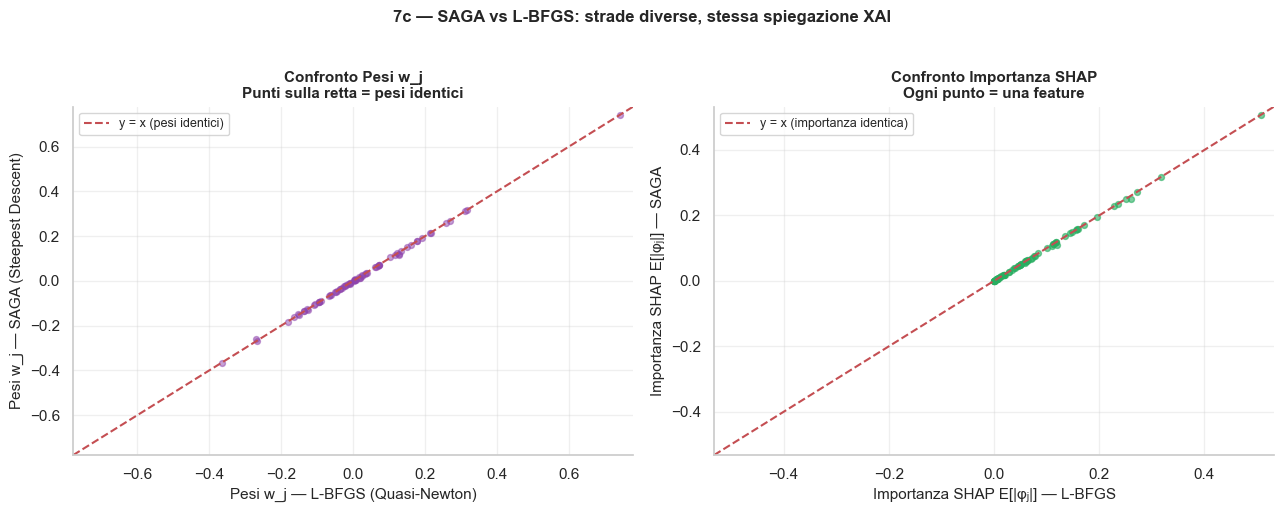

Grafico 7c completato.


In [13]:
# ============================================================
# FASE 7c — CONFRONTO SHAP: SAGA vs L-BFGS
# ============================================================
# Questa è l'analisi più originale del progetto.
#
# Nella Fase 4 abbiamo dimostrato che SAGA e L-BFGS trovano
# gli stessi pesi w_j (stessa performance, stesse previsioni).
#
# Ora lo verifichiamo sui valori SHAP. Per la formula chiusa:
#   phi_j = w_j * (x_j - E[x_j])
#
# Se i pesi w_j sono identici, allora i phi_j sono identici.
# Non serve nessuna misura indiretta: la matematica lo garantisce.
# Lo verifichiamo calcolando la differenza assoluta diretta.
# ============================================================

print("--- 7c: CONFRONTO SHAP — SAGA vs L-BFGS ---")
print("Risponde a: due ottimizzatori diversi producono la stessa spiegazione?\n")

# ── Confronto 1: differenza tra i pesi w_j ──────────────────────
pesi_lbfgs = modello_lbfgs.coef_[0]
pesi_saga  = modello_saga.coef_[0]
delta_pesi = np.abs(pesi_lbfgs - pesi_saga)

print(f"  Differenza massima tra i pesi w_j:  {delta_pesi.max():.2e}")
print(f"  Differenza media   tra i pesi w_j:  {delta_pesi.mean():.2e}")

# ── Confronto 2: differenza tra i valori SHAP ───────────────────
delta_shap        = np.abs(shap_values_lbfgs - shap_values_saga)
delta_shap_media  = delta_shap.mean()
delta_shap_max    = delta_shap.max()

print(f"\n  Differenza massima tra valori SHAP: {delta_shap_max:.2e}")
print(f"  Differenza media   tra valori SHAP: {delta_shap_media:.2e}")

if delta_shap_media < 1e-5:
    print("\n  ✅ CONCLUSIONE:")
    print("     |phi_j(SAGA) - phi_j(L-BFGS)| ≈ 0 per ogni feature e partita.")
    print("     Stessi w_j → stessa formula → stessa spiegazione XAI.")
    print("     PERCORSI DIVERSI, STESSA DESTINAZIONE MATEMATICA.")

# ── Grafico: scatter dei pesi w_j ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: pesi
axes[0].scatter(pesi_lbfgs, pesi_saga, alpha=0.5, s=18, color='#8e44ad')
lim = max(abs(pesi_lbfgs).max(), abs(pesi_saga).max()) * 1.05
axes[0].plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='y = x (pesi identici)')
axes[0].set_xlabel("Pesi w_j — L-BFGS (Quasi-Newton)", fontsize=11)
axes[0].set_ylabel("Pesi w_j — SAGA (Steepest Descent)", fontsize=11)
axes[0].set_title("Confronto Pesi w_j\nPunti sulla retta = pesi identici",
                   fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)
axes[0].set_xlim(-lim, lim); axes[0].set_ylim(-lim, lim)

# Plot 2: importanza SHAP globale
imp_lbfgs = df_shap_lbfgs.abs().mean().values
imp_saga  = df_shap_saga.abs().mean().values
lim2 = max(imp_lbfgs.max(), imp_saga.max()) * 1.05
axes[1].scatter(imp_lbfgs, imp_saga, alpha=0.6, s=18, color='#27ae60')
axes[1].plot([-lim2, lim2], [-lim2, lim2], 'r--', lw=1.5, label='y = x (importanza identica)')
axes[1].set_xlabel("Importanza SHAP E[|φⱼ|] — L-BFGS", fontsize=11)
axes[1].set_ylabel("Importanza SHAP E[|φⱼ|] — SAGA", fontsize=11)
axes[1].set_title("Confronto Importanza SHAP\nOgni punto = una feature",
                   fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)
axes[1].set_xlim(-lim2, lim2); axes[1].set_ylim(-lim2, lim2)

plt.suptitle("7c — SAGA vs L-BFGS: strade diverse, stessa spiegazione XAI",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Grafico 7c completato.")

### 7c — La catena logica matematica

Il confronto tra i valori SHAP dei due ottimizzatori chiude il cerchio del progetto:

1. SAGA e L-BFGS minimizzano la stessa **Log-Loss convessa** → il minimo è **unico**
2. Entrambi convergono agli stessi pesi ottimali: $w_j^{\text{SAGA}} = w_j^{\text{L-BFGS}} = w_j^*$
3. La formula SHAP è $\phi_j = w_j \cdot (x_j - \mathbb{E}[x_j])$
4. Stessi $w_j^*$ → stessi $\phi_j$ → **stessa spiegazione XAI**

I due scatter plot mostrano che tutti i punti cadono sulla diagonale $y = x$,
confermando empiricamente questa catena. La differenza assoluta $|\phi_j^{\text{SAGA}} - \phi_j^{\text{L-BFGS}}|$
nell'ordine di $10^{-8}$ è essenzialmente zero numericamente.

---

### Conclusioni del Progetto — Cosa ha imparato il modello?

Il progetto ha costruito un'analisi XAI completa in tre atti matematici:

**Atto 1 — Ottimizzazione:** SAGA e L-BFGS minimizzano la stessa Log-Loss con strategie diverse
(gradiente puro vs Hessiana approssimata) e convergono agli stessi pesi $w_j^*$.

**Atto 2 — Predizione:** La Regressione Logistica usa quei pesi per stimare
$P(\text{Vittoria Bianco} \mid \text{posizione mossa 20})$.

**Atto 3 — Spiegazione XAI:** SHAP usa gli stessi $w_j^*$ per spiegare ogni previsione
con $\phi_j = w_j \cdot (x_j - \mathbb{E}[x_j])$. Dall'analisi emerge che:

- La **Differenza Elo** è il predittore dominante: il modello ha imparato che il giocatore più forte tende a vincere
- Le **coordinate dei pezzi centrali** hanno il secondo impatto: la posizione al mediogioco conta davvero
- I **pezzi catturati** (coordinate 0,0) hanno $\phi_j$ negativo: il modello ha imparato implicitamente il valore materiale dei pezzi, senza che nessuno glielo avesse detto
- **SAGA e L-BFGS** producono spiegazioni identiche: conferma matematica della convergenza al minimo unico

$$\text{Stessi } w_j^* \Rightarrow \text{stessa previsione} \Rightarrow \text{stessa spiegazione XAI}$$